# Host genotype effect on flower microbiome

Do flowers from the **same parent tree** share more similar microbial communities than flowers from different trees on the same farm, or from different farms?

Datasets: **16S bacteria** and **ITS1 fungi** (biological samples only).

Distances: **Bray-Curtis** (relative abundance) and **Aitchison** (CLR-Euclidean).

Tests per distance matrix:
- Pairwise partitioning: within-tree / within-farm between-tree / between-farm
- Mann-Whitney U (one-sided)
- PERMANOVA (999 permutations, grouping by tree_id)

In [1]:
from pathlib import Path
import colorsys

import biom
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform
from skbio.stats.composition import clr
from skbio.stats.distance import DistanceMatrix, permanova


## Paths

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR     = PROJECT_ROOT / "results" / "biom"
METADATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR    :", DATA_DIR)
print("METADATA_DIR:", METADATA_DIR)

PROJECT_ROOT: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome
DATA_DIR    : /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/biom
METADATA_DIR: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/data


## Data loading

Biological samples only for both amplicon types.

In [3]:
# ── 16S bacteria (bio samples only) ─────────────────────────────────────────
table_16s     = biom.load_table(str(DATA_DIR / 'cfm_16s_bacteria_biosamples_feature-table.biom'))
sids_16s      = list(table_16s.ids(axis='sample'))
print(f'16S:  {table_16s.shape[1]} samples x {table_16s.shape[0]} ASVs')

# ── ITS1 fungi (bio samples only) ────────────────────────────────────────────
table_its1    = biom.load_table(str(DATA_DIR / 'cfm_its1_fungi_biosamples_feature-table.biom'))
sids_its1     = list(table_its1.ids(axis='sample'))
print(f'ITS1: {table_its1.shape[1]} samples x {table_its1.shape[0]} ASVs')

# ── Metadata (load once, reindex per dataset) ─────────────────────────────────
metadata_raw = (
    pd.read_excel(METADATA_DIR / 'sample_metadata_with_microscopy.xlsx', index_col=0)
    .iloc[1:]   # drop QIIME2 type-hint row
)
metadata_raw.index.name = 'sample_id'
_num_cols = ['dna_conc_hs_16s', 'dna_conc_hs_its1',
             'pi_dic', 'pi_clsm', 'callose_plug_index', 'fungal_colonization_score']
for col in _num_cols:
    if col in metadata_raw.columns:
        metadata_raw[col] = pd.to_numeric(metadata_raw[col], errors='coerce')

meta_16s  = metadata_raw.reindex(sids_16s)
meta_its1 = metadata_raw.reindex(sids_its1)
print(f'Metadata: {metadata_raw.shape[1]} columns')
print('16S sample types:', meta_16s['sample_type'].value_counts().to_dict())
print('ITS1 sample types:', meta_its1['sample_type'].value_counts().to_dict())


16S:  294 samples x 25035 ASVs
ITS1: 294 samples x 11929 ASVs
Metadata: 33 columns
16S sample types: {'bagged_flower': 147, 'unbagged_flower': 147}
ITS1 sample types: {'bagged_flower': 147, 'unbagged_flower': 147}


## Colour palettes

In [4]:
SAMPLE_TYPE_COLORS = {
    'bagged_flower':        '#4C72B0',
    'unbagged_flower':      '#DD8452',
    'extraction_control':   '#55A868',
    'negative_pcr_control': '#C44E52',
    'mock_community':       '#8172B2',
}
CTRL_COLOR = '#cccccc'

# Use 16S metadata for palette construction (bio samples expected identical)
_bio_mask     = meta_16s['sample_type'].isin(['bagged_flower', 'unbagged_flower'])
farm_ids_uniq = sorted(meta_16s.loc[_bio_mask, 'farm_id'].dropna().unique())
farm_palette  = dict(zip(farm_ids_uniq, sns.color_palette('Set2', len(farm_ids_uniq))))

def make_tree_palette(farm_ids_list, n_trees=7):
    pal = {}
    n_f = len(farm_ids_list)
    for i, farm in enumerate(farm_ids_list):
        hue = i / n_f
        for t in range(1, n_trees + 1):
            lightness = 0.75 - 0.45 * (t - 1) / (n_trees - 1)
            r, g, b   = colorsys.hls_to_rgb(hue, lightness, 0.72)
            pal[f'{farm}{t}'] = (r, g, b)
    return pal

tree_palette_49 = make_tree_palette(farm_ids_uniq)
dist_colors     = ['#4C72B0', '#DD8452', '#55A868']  # within-tree / within-farm / between-farm
dist_labels     = ['within-tree', 'within-farm\nbetween-tree', 'between-farm']
print('Palettes ready. Farms:', farm_ids_uniq)


Palettes ready. Farms: ['ib', 'kk', 'mt', 'sa', 'vi', 'vr', 'yb']


## Distance matrix computation

In [5]:
def multiplicative_replacement(mat, delta=None):
    mat = np.asarray(mat, dtype=float)
    n   = mat.shape[1]
    if delta is None:
        delta = 1.0 / n ** 2
    result = mat.copy()
    for i in range(len(result)):
        zm = result[i] == 0
        k  = zm.sum()
        if k:
            result[i, zm]  = delta
            result[i, ~zm] *= 1.0 - k * delta
    return result


def compute_distances(biom_table, meta, label):
    sids   = list(biom_table.ids(axis='sample'))
    counts = pd.DataFrame(biom_table.matrix_data.toarray().T, index=sids,
                          columns=list(biom_table.ids(axis='observation')))
    # drop zero-sum samples if any
    ok = counts.sum(axis=1) > 0
    if (~ok).any():
        print(f'  [{label}] dropping {(~ok).sum()} zero-sum samples')
        counts = counts[ok];  sids = counts.index.tolist()

    rel = counts.div(counts.sum(axis=1), axis=0)

    # Bray-Curtis
    bc_c   = pdist(rel.values, metric='braycurtis')
    bc_mat = squareform(bc_c)
    bc_df  = pd.DataFrame(bc_mat, index=sids, columns=sids)

    # Aitchison (CLR-Euclidean)
    comp    = multiplicative_replacement(rel.values)
    clr_arr = clr(comp)
    ait_c   = pdist(clr_arr, metric='euclidean')
    ait_mat = squareform(ait_c)
    ait_df  = pd.DataFrame(ait_mat, index=sids, columns=sids)

    meta_ds = meta.reindex(sids)
    return dict(label=label, sids=sids, meta=meta_ds,
                bc_df=bc_df, ait_df=ait_df)


print('Computing 16S distances ...')
ds_16s  = compute_distances(table_16s,  meta_16s,  '16S bacteria')
print(f'  {len(ds_16s["sids"])} samples')

print('Computing ITS1 distances ...')
ds_its1 = compute_distances(table_its1, meta_its1, 'ITS1 fungi')
print(f'  {len(ds_its1["sids"])} samples')
print('Done.')


Computing 16S distances ...
  294 samples
Computing ITS1 distances ...
  294 samples
Done.


## Distance partitioning: within-tree / within-farm / between-farm

For each pair of biological samples, distances are classified by their relationship (same tree, same farm, different farm).

In [6]:
def partition_distances(ds):
    sids         = ds['sids']
    meta_ds      = ds['meta']
    n            = len(sids)
    tree_ids_arr = np.array([meta_ds.loc[s, 'tree_id'] for s in sids])
    farm_ids_arr = np.array([meta_ds.loc[s, 'farm_id'] for s in sids])
    rows, cols   = np.triu_indices(n, k=1)
    same_tree    = tree_ids_arr[rows] == tree_ids_arr[cols]
    same_farm    = farm_ids_arr[rows] == farm_ids_arr[cols]

    out = {}
    for dist_type in ('bc', 'ait'):
        mat  = ds['bc_df'].values if dist_type == 'bc' else ds['ait_df'].values
        dists = mat[rows, cols]
        within_tree  = dists[same_tree]
        within_farm  = dists[~same_tree &  same_farm]
        between_farm = dists[~same_farm]

        u1, p1 = stats.mannwhitneyu(within_tree,  within_farm,  alternative='less')
        u2, p2 = stats.mannwhitneyu(within_farm,  between_farm, alternative='less')

        dist_label = 'Bray-Curtis' if dist_type == 'bc' else 'Aitchison'
        dm   = DistanceMatrix(np.ascontiguousarray(mat), ids=sids)
        perm = permanova(dm, tree_ids_arr.tolist(), permutations=999)

        print(f'\n{ds["label"]} -- {dist_label}')
        print(f'  within-tree:      n={len(within_tree):4d}  mean={within_tree.mean():.4f}  median={np.median(within_tree):.4f}')
        print(f'  within-farm:      n={len(within_farm):4d}  mean={within_farm.mean():.4f}  median={np.median(within_farm):.4f}')
        print(f'  between-farm:     n={len(between_farm):4d}  mean={between_farm.mean():.4f}  median={np.median(between_farm):.4f}')
        print(f'  MWU within-tree < within-farm:   p={p1:.4e}')
        print(f'  MWU within-farm < between-farm:  p={p2:.4e}')
        print(f'  PERMANOVA pseudo-F={perm["test statistic"]:.3f}  p={perm["p-value"]:.3f}')

        out[dist_type] = dict(
            within_tree=within_tree, within_farm=within_farm, between_farm=between_farm,
            p1=p1, p2=p2, perm=perm, tree_ids_arr=tree_ids_arr,
            mat=mat, sids=sids,
        )
    return out


print('Running 16S partitioning ...')
part_16s  = partition_distances(ds_16s)
print('\nRunning ITS1 partitioning ...')
part_its1 = partition_distances(ds_its1)
print('\nDone.')


Running 16S partitioning ...

16S bacteria -- Bray-Curtis
  within-tree:      n= 735  mean=0.8140  median=0.8532
  within-farm:      n=5292  mean=0.8403  median=0.8777
  between-farm:     n=37044  mean=0.8593  median=0.8995
  MWU within-tree < within-farm:   p=3.0082e-06
  MWU within-farm < between-farm:  p=5.8218e-21
  PERMANOVA pseudo-F=1.569  p=0.001

16S bacteria -- Aitchison
  within-tree:      n= 735  mean=251.1561  median=242.6678
  within-farm:      n=5292  mean=254.3843  median=245.3791
  between-farm:     n=37044  mean=256.2297  median=245.9317
  MWU within-tree < within-farm:   p=1.0610e-01
  MWU within-farm < between-farm:  p=3.0925e-02
  PERMANOVA pseudo-F=1.209  p=0.001

Running ITS1 partitioning ...

ITS1 fungi -- Bray-Curtis
  within-tree:      n= 735  mean=0.7870  median=0.8353
  within-farm:      n=5292  mean=0.8210  median=0.8547
  between-farm:     n=37044  mean=0.8745  median=0.8908
  MWU within-tree < within-farm:   p=3.3531e-06
  MWU within-farm < between-farm:  

## Violin plots: distance partitioning

One row per dataset (16S / ITS1), one column per distance metric (BC / Aitchison).

Saved: /mnt/c/Users/nmmak/Desktop/cacao_flower_microbiome/results/figures/host_genotype_distances.png


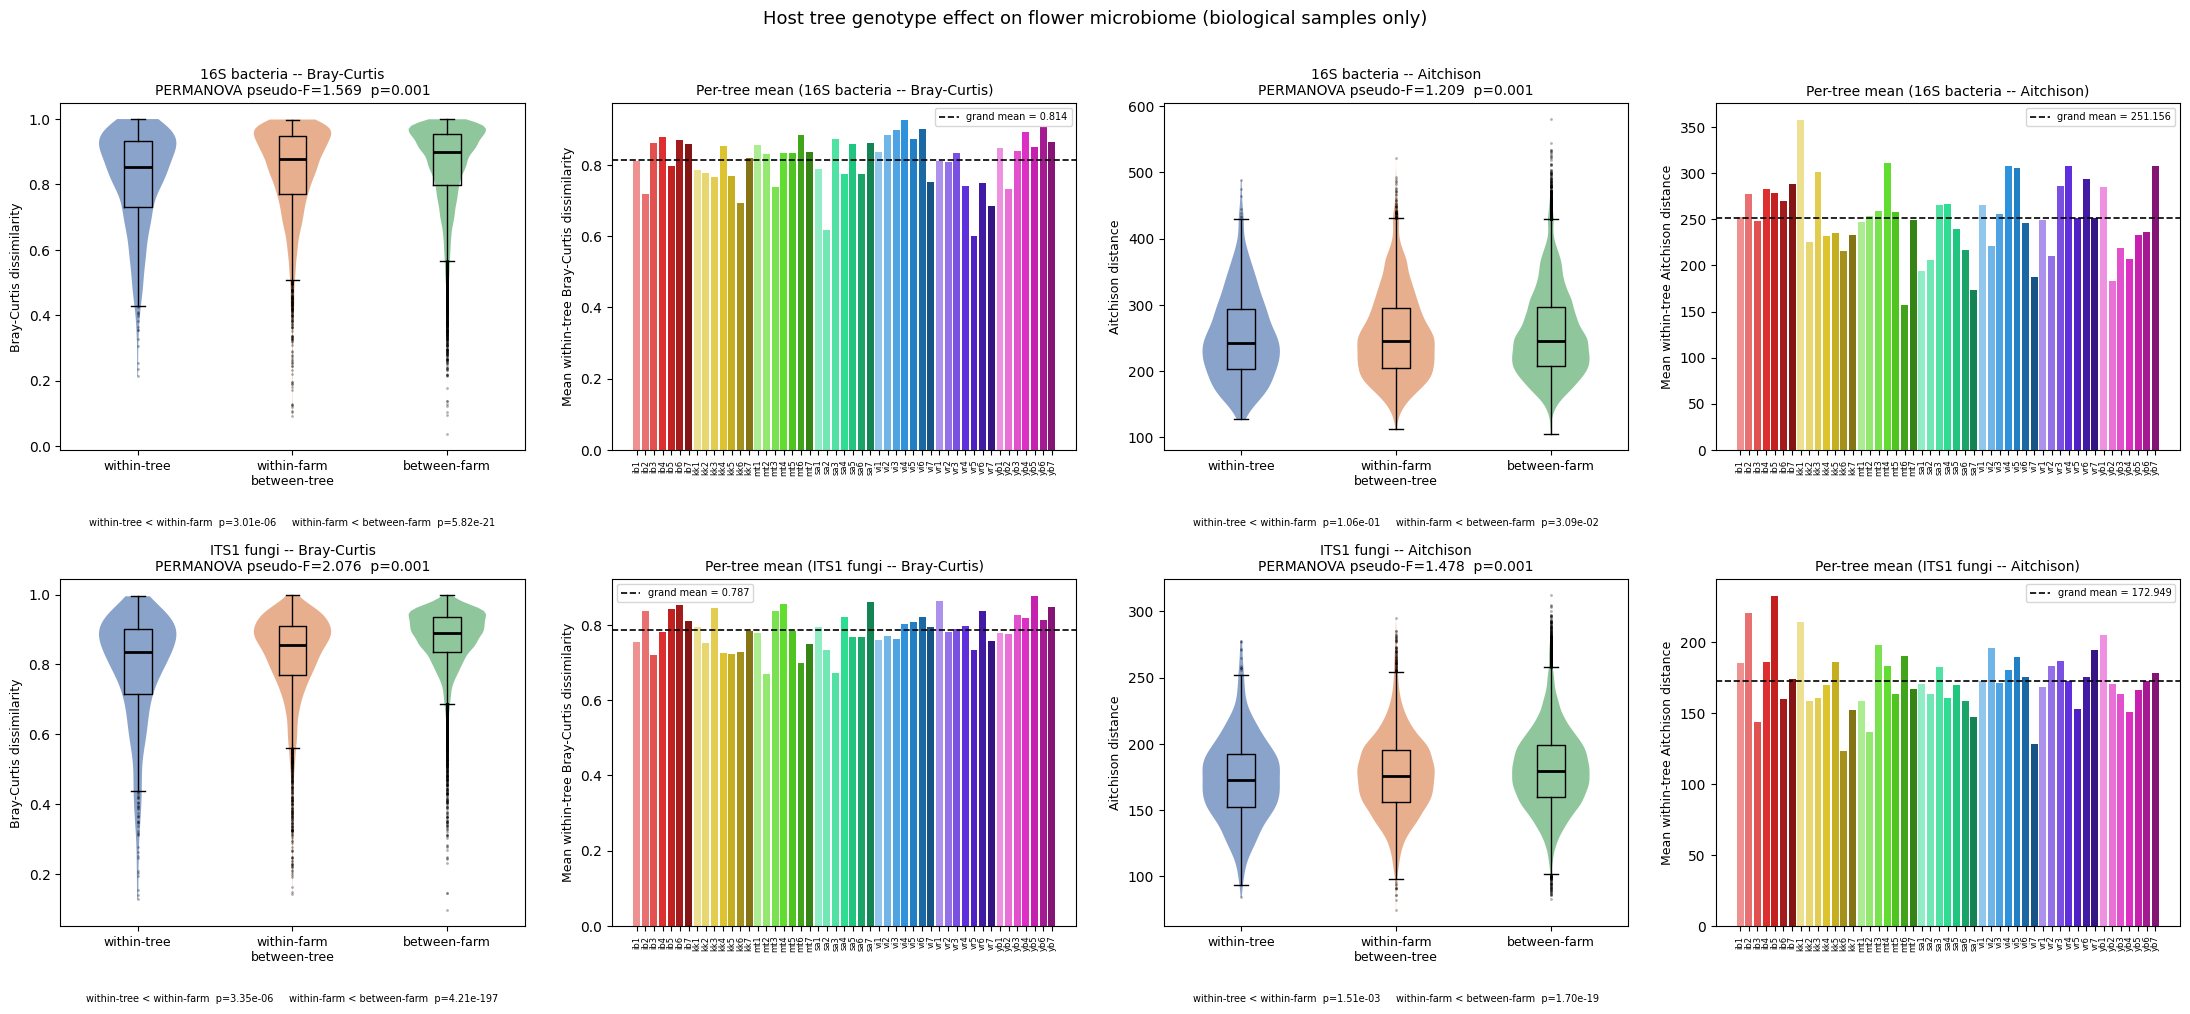

In [7]:
def violin_panel(ax, data_groups, labels, colors, title, ylabel, p1, p2):
    parts = ax.violinplot(data_groups, positions=range(3),
                          showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color);  pc.set_alpha(0.65)
    ax.boxplot(data_groups, positions=range(3), widths=0.18, patch_artist=False,
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.text(0.5, -0.22,
            f'within-tree < within-farm  p={p1:.2e}     within-farm < between-farm  p={p2:.2e}',
            ha='center', transform=ax.transAxes, fontsize=7)


def per_tree_bar(ax, mat, tree_ids_arr, sids, tree_palette, ylabel, grand_mean):
    unique_trees = sorted(set(tree_ids_arr))
    per_tree = []
    for t in unique_trees:
        idx = np.where(tree_ids_arr == t)[0]
        if len(idx) < 2:
            continue
        sub = mat[np.ix_(idx, idx)]
        vals = sub[np.triu_indices(len(idx), k=1)]
        per_tree.append((t, vals.mean()))
    if not per_tree:
        ax.text(0.5, 0.5, 'no trees with >1 sample', ha='center', transform=ax.transAxes)
        return
    t_labels, t_means = zip(*per_tree)
    ax.bar(range(len(t_labels)), t_means,
           color=[tree_palette.get(str(t), '#cccccc') for t in t_labels], width=0.8)
    ax.axhline(grand_mean, color='black', ls='--', lw=1.2,
               label=f'grand mean = {grand_mean:.3f}')
    ax.set_xticks(range(len(t_labels)))
    ax.set_xticklabels(t_labels, rotation=90, fontsize=6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=7)


datasets   = [('16S bacteria', part_16s,  ds_16s),
              ('ITS1 fungi',   part_its1, ds_its1)]
dist_types = [('bc',  'Bray-Curtis', 'Bray-Curtis dissimilarity'),
              ('ait', 'Aitchison',   'Aitchison distance')]

fig, axes = plt.subplots(len(datasets), len(dist_types) * 2,
                          figsize=(22, 5 * len(datasets)))

for row_i, (ds_label, part, ds) in enumerate(datasets):
    for col_i, (dt, dt_short, dt_ylabel) in enumerate(dist_types):
        p  = part[dt]
        # Violin
        ax_v = axes[row_i, col_i * 2]
        violin_panel(ax_v,
                     [p['within_tree'], p['within_farm'], p['between_farm']],
                     dist_labels, dist_colors,
                     f'{ds_label} -- {dt_short}\n'
                     f'PERMANOVA pseudo-F={p["perm"]["test statistic"]:.3f}  '
                     f'p={p["perm"]["p-value"]:.3f}',
                     dt_ylabel, p['p1'], p['p2'])
        # Per-tree bar
        ax_b = axes[row_i, col_i * 2 + 1]
        per_tree_bar(ax_b, p['mat'], p['tree_ids_arr'], p['sids'],
                     tree_palette_49,
                     f'Mean within-tree {dt_ylabel}',
                     p['within_tree'].mean())
        ax_b.set_title(f'Per-tree mean ({ds_label} -- {dt_short})', fontsize=10)

plt.suptitle('Host tree genotype effect on flower microbiome (biological samples only)',
             fontsize=13, y=1.01)
plt.tight_layout()
_out = PROJECT_ROOT / 'results' / 'figures' / 'host_genotype_distances.png'
_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(_out, dpi=130, bbox_inches='tight')
print(f'Saved: {_out}')
plt.show()
